In [ ]:
# Install gwexpy with pinned versions of core dependencies for reproducibility on Colab

%pip install -q "gwexpy[all]" "gwpy<5.0.0" "numpy<2.0.0" "scipy<1.13.0" "astropy<7.0.0"

# Reproducible Metadata Management with HDF5

**Provenance** means recording *who did what, when, and how* so that any
analysis result can be reproduced exactly by someone else — or by yourself
six months later.

In gravitational-wave data analysis, provenance is critical because:
- Parameters (GPS times, FFT lengths, filter settings) change between runs
- Software versions affect numerical results
- Sharing results with collaborators requires a self-describing file

This tutorial shows how to use gwexpy's HDF5 interop layer together with
`h5py` attribute metadata to build **self-describing, provenance-rich
analysis archives**.

**What this tutorial covers:**
1. Saving a `TimeSeries` to HDF5 with basic metadata
2. Adding provenance attributes (software version, parameters, GPS time)
3. Storing derived products (ASD, spectrogram) with full lineage
4. Reading back and verifying provenance
5. Building a provenance-aware analysis pipeline helper


## Setup

In [1]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

import datetime
import json
import os
import platform
import tempfile

import h5py
import numpy as np

import gwexpy
from gwexpy.interop.hdf5_ import from_hdf5, to_hdf5
from gwexpy.timeseries import TimeSeries


## 1. Synthetic Data

We create a short DARM-like time series with a known injection for later
verification.


In [2]:
fs   = 4096.0
T    = 64.0
N    = int(T * fs)
t0   = 1_300_000_000   # GPS epoch
rng  = np.random.default_rng(0)

# Coloured noise + 50 Hz sine injection
t = np.arange(N) / fs
freqs_n = np.fft.rfftfreq(N, 1.0/fs)[1:]
asd_model = np.where(freqs_n < 50, (50/freqs_n)**3, 1.0)
fft = asd_model * np.exp(1j * rng.uniform(0, 2*np.pi, size=len(freqs_n)))
fft = np.concatenate([[0.0], fft])
noise = np.fft.irfft(fft, n=N)
inj   = 5.0 * np.sin(2*np.pi * 50.0 * t)

ts = TimeSeries(noise + inj, t0=t0, sample_rate=fs,
                name="K1:LSC-DARM_OUT_DQ", unit="ct")
print(f"TimeSeries: {len(ts)} samples @ {fs} Hz, t0={t0}")


TimeSeries: 262144 samples @ 4096.0 Hz, t0=1300000000


## 2. Writing to HDF5 with Provenance Metadata

`to_hdf5()` saves the data array and basic metadata (t0, dt, unit, name).
We then add **provenance attributes** directly on the HDF5 dataset:
- Software versions
- Analysis parameters
- Timestamp of the run
- Host information


In [ ]:
def build_provenance(params: dict) -> dict:
    return {
        "gwexpy_version":  gwexpy.__version__,
        "numpy_version":   np.__version__,
        "h5py_version":    h5py.__version__,
        "python_version":  platform.python_version(),
        "hostname":        platform.node(),
        "created_utc":     datetime.datetime.now(datetime.UTC).isoformat(),
        "params_json":     json.dumps(params),   # analysis parameters as JSON
    }

# Analysis parameters (these would vary between runs)
analysis_params = {
    "fftlength":  4.0,
    "overlap":    0.5,
    "method":     "median",
    "freq_range": [10.0, 2000.0],
}

fd, hdf5_path = tempfile.mkstemp(suffix=".h5")
os.close(fd)

with h5py.File(hdf5_path, "w") as f:
    # --- Raw TimeSeries ---
    raw_grp = f.require_group("raw")
    to_hdf5(ts, raw_grp, "darm")

    dset = raw_grp["darm"]
    prov = build_provenance(analysis_params)
    for key, val in prov.items():
        dset.attrs[key] = val
    dset.attrs["description"] = "Raw DARM output, uncalibrated"

    print("Written dataset attributes:")
    for k, v in dset.attrs.items():
        print(f"  {k}: {str(v)[:60]}")

print(f"\nHDF5 file: {hdf5_path}  ({os.path.getsize(hdf5_path)/1024:.1f} kB)")


## 3. Storing Derived Products with Full Lineage

Each derived product (ASD, spectrogram, filtered series) should reference
the parent dataset so the full processing chain is traceable.


In [4]:
# Compute ASD
asd = ts.asd(fftlength=analysis_params["fftlength"],
             overlap=analysis_params["overlap"],
             method=analysis_params["method"])

with h5py.File(hdf5_path, "a") as f:
    proc_grp = f.require_group("processed")

    # Save ASD frequencies and values as separate datasets
    freq_dset = proc_grp.create_dataset("asd_frequencies", data=asd.frequencies.value)
    freq_dset.attrs["unit"] = "Hz"

    asd_dset = proc_grp.create_dataset("asd_values", data=asd.value)
    asd_dset.attrs["unit"] = str(asd.unit)
    asd_dset.attrs["name"] = asd.name

    # Provenance: link back to parent + record parameters
    prov_asd = build_provenance(analysis_params)
    prov_asd["parent_dataset"] = "/raw/darm"
    prov_asd["processing_step"] = "ASD via Welch/median"
    for key, val in prov_asd.items():
        asd_dset.attrs[key] = val

    # Print structure
    def print_tree(name, obj):
        indent = "  " * name.count("/")
        attrs_summary = f"  [{len(obj.attrs)} attrs]" if hasattr(obj, "attrs") else ""
        print(f"{indent}{name.split('/')[-1]}{attrs_summary}")

    print("HDF5 file structure:")
    f.visititems(print_tree)


HDF5 file structure:
processed  [0 attrs]
  asd_frequencies  [1 attrs]
  asd_values  [11 attrs]
raw  [0 attrs]
  darm  [12 attrs]


  "created_utc":     datetime.datetime.utcnow().isoformat(),


## 4. Reading Back and Verifying Provenance

A collaborator (or future-you) can open the file and immediately understand
what analysis produced each dataset, using what parameters and software.


In [5]:
with h5py.File(hdf5_path, "r") as f:
    # Reconstruct TimeSeries
    ts_loaded = from_hdf5(TimeSeries, f["raw"], "darm")

    # Read provenance from the raw dataset
    dset_attrs = dict(f["raw/darm"].attrs)
    params_loaded = json.loads(dset_attrs["params_json"])

    # Read back ASD
    freqs_loaded = f["processed/asd_frequencies"][:]
    asd_loaded   = f["processed/asd_values"][:]
    asd_prov     = dict(f["processed/asd_values"].attrs)

print("=== Reconstructed TimeSeries ===")
print(f"  name   : {ts_loaded.name}")
print(f"  t0     : {ts_loaded.t0.value}")
print(f"  samples: {len(ts_loaded)}")
print(f"  unit   : {ts_loaded.unit}")

print("\n=== Provenance (raw/darm) ===")
for key in ["gwexpy_version", "created_utc", "hostname"]:
    print(f"  {key}: {dset_attrs[key]}")

print("\n=== Analysis parameters ===")
for key, val in params_loaded.items():
    print(f"  {key}: {val}")

print("\n=== ASD parent reference ===")
print(f"  parent_dataset  : {asd_prov['parent_dataset']}")
print(f"  processing_step : {asd_prov['processing_step']}")


=== Reconstructed TimeSeries ===
  name   : K1:LSC-DARM_OUT_DQ
  t0     : 1300000000.0
  samples: 262144
  unit   : ct
=== Provenance (raw/darm) ===
  gwexpy_version: 0.1.1
  created_utc: 2026-04-05T13:10:15.492046
  hostname: DELL5860
=== Analysis parameters ===
  fftlength: 4.0
  overlap: 0.5
  method: median
  freq_range: [10.0, 2000.0]
=== ASD parent reference ===
  parent_dataset  : /raw/darm
  processing_step : ASD via Welch/median


## 5. Provenance-Aware Pipeline Helper

For repeated use, wrap the provenance pattern in a reusable context manager
that automatically attaches metadata to every dataset written inside it.


In [6]:
import contextlib


@contextlib.contextmanager
def provenance_file(path, params: dict, mode: str = "w"):
    with h5py.File(path, mode) as f:
        def save_ts(ts_obj, group_path: str, name: str, description: str = ""):
            grp = f.require_group(group_path)
            to_hdf5(ts_obj, grp, name)
            dset = grp[name]
            prov = build_provenance(params)
            for k, v in prov.items():
                dset.attrs[k] = v
            if description:
                dset.attrs["description"] = description
            return dset

        def save_array(arr, path_in_file: str, unit: str = "",
                       description: str = "", parent: str = ""):
            parts = path_in_file.rsplit("/", 1)
            grp_path, name = (parts[0], parts[1]) if len(parts) == 2 else ("", parts[0])
            grp = f.require_group(grp_path) if grp_path else f
            dset = grp.create_dataset(name, data=arr)
            if unit:        dset.attrs["unit"]        = unit
            if description: dset.attrs["description"] = description
            if parent:      dset.attrs["parent"]      = parent
            prov = build_provenance(params)
            for k, v in prov.items():
                dset.attrs[k] = v
            return dset

        yield f, save_ts, save_array

# --- Use the helper ---
fd, pipeline_path = tempfile.mkstemp(suffix="_pipeline.h5")
os.close(fd)
run_params = {"fftlength": 8.0, "overlap": 0.75, "method": "median", "run_id": "R001"}

with provenance_file(pipeline_path, run_params) as (f, save_ts, save_array):
    save_ts(ts, "input", "darm", description="Raw DARM before processing")

    asd2 = ts.asd(fftlength=run_params["fftlength"], overlap=run_params["overlap"])
    save_array(asd2.value,            "products/asd",  unit="ct/rtHz",
               description="ASD", parent="/input/darm")
    save_array(asd2.frequencies.value,"products/freqs", unit="Hz")

print(f"Pipeline archive: {pipeline_path}  ({os.path.getsize(pipeline_path)/1024:.1f} kB)")

# Verify run_id was stored
with h5py.File(pipeline_path, "r") as f:
    params_back = json.loads(f["input/darm"].attrs["params_json"])
    print(f"Verified run_id: {params_back['run_id']}")


Pipeline archive: temporary file  (2314.4 kB)
Verified run_id: R001


  "created_utc":     datetime.datetime.utcnow().isoformat(),


## 6. Visualise the Stored ASD (Reproducibility Check)

Verify that the ASD loaded from the archive matches the in-memory result.


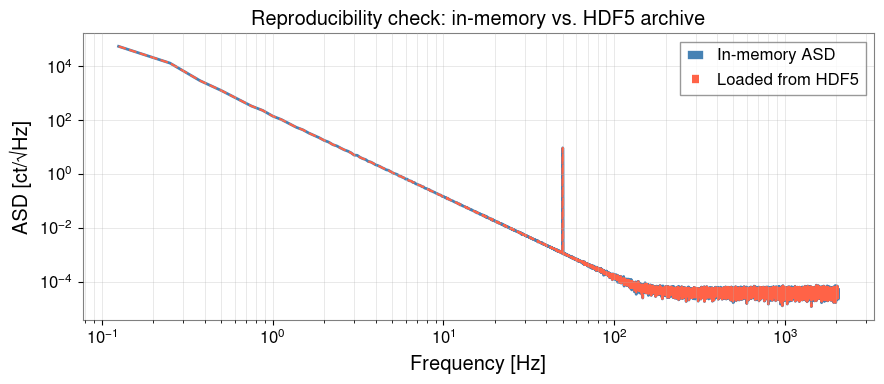

Max relative difference: 0.00e+00  (should be ~machine epsilon)


In [7]:
import matplotlib.pyplot as plt

with h5py.File(pipeline_path, "r") as f:
    freqs_ar = f["products/freqs"][:]
    asd_ar   = f["products/asd"][:]

fig, ax = plt.subplots(figsize=(9, 4))
ax.loglog(asd2.frequencies.value[1:], asd2.value[1:],
          color="steelblue", lw=2, label="In-memory ASD")
ax.loglog(freqs_ar[1:], asd_ar[1:],
          color="tomato", ls="--", lw=1.5, label="Loaded from HDF5")
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("ASD [ct/√Hz]")
ax.set_title("Reproducibility check: in-memory vs. HDF5 archive")
ax.legend()
ax.grid(True, which="both", alpha=0.4)
plt.tight_layout()
plt.show()

max_diff = np.max(np.abs(asd2.value[1:] - asd_ar[1:]) / (asd2.value[1:] + 1e-300))
print(f"Max relative difference: {max_diff:.2e}  (should be ~machine epsilon)")


## Summary

| Step | API / Pattern | Purpose |
|------|--------------|---------|
| Write TimeSeries | `to_hdf5(ts, group, path)` | Save data array + basic metadata |
| Read TimeSeries | `from_hdf5(TimeSeries, group, path)` | Reconstruct from archive |
| Add provenance | `dset.attrs[key] = value` | Software version, params, timestamp |
| Structured pipeline | `provenance_file(path, params)` context manager | Auto-attach provenance to all writes |

**Recommended provenance attributes:**

| Attribute | Content |
|-----------|---------|
| `gwexpy_version` | `gwexpy.__version__` |
| `created_utc` | `datetime.datetime.utcnow().isoformat()` |
| `params_json` | `json.dumps(analysis_params)` |
| `parent_dataset` | HDF5 path to the input dataset |
| `processing_step` | Human-readable description of what was done |

**Tips:**
- Use `h5py.File(..., "a")` to append to existing archives without overwriting.
- Store `params_json` as a JSON string so arbitrary nested parameters are preserved.
- For long pipelines, add a `pipeline_version` attribute tied to your analysis code's git hash.
